In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config, extract_features_from_flows
from src.splits.io import load_splits

paths = load_paths()
logger = setup_logger(level="INFO")

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
print("="*60)
print("1. RAW DATA ANALYSIS")
print("="*60)

# Load Raw Flows
logger.info("Loading raw flows...")
vnat_flows = pd.read_parquet(paths.data_processed / "vnat" / "flows.parquet")
iscx_flows = pd.read_parquet(paths.data_processed / "iscx" / "flows.parquet")

vnat_flows["dataset"] = "vnat"
iscx_flows["dataset"] = "iscx"

print(f"VNAT Flows: {len(vnat_flows)}")
print(f"ISCX Flows: {len(iscx_flows)}")

# Combine for easier analysis
all_flows = pd.concat([vnat_flows, iscx_flows], ignore_index=True)


1. RAW DATA ANALYSIS
2026-03-07 04:03:36 | INFO | ai-vpn-firewall | Loading raw flows...
VNAT Flows: 33711
ISCX Flows: 76687



--- Class Balance (Raw) ---
label        0      1  total  vpn_ratio
dataset                                
iscx     54254  22433  76687   0.292527
vnat     33332    379  33711   0.011243


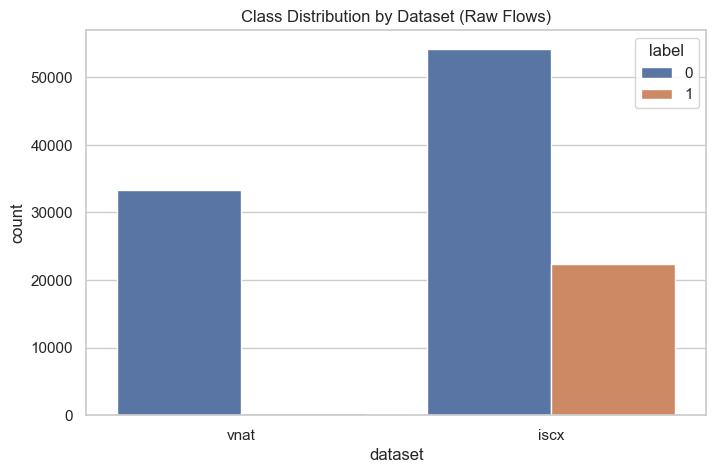

In [3]:
# 1.1 Class Balance
print("\n--- Class Balance (Raw) ---")
balance = all_flows.groupby(["dataset", "label"]).size().unstack(fill_value=0)
balance["total"] = balance.sum(axis=1)
balance["vpn_ratio"] = balance[1] / balance["total"]
print(balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=all_flows, x="dataset", hue="label")
plt.title("Class Distribution by Dataset (Raw Flows)")
plt.show()


In [4]:
# 1.2 Capture Analysis
print("\n--- Capture Analysis ---")
# Check for mixed labels in captures
mixed_caps = all_flows.groupby("capture_id")["label"].nunique()
mixed_caps = mixed_caps[mixed_caps > 1]

if len(mixed_caps) > 0:
    print(f"WARNING: Found {len(mixed_caps)} captures with mixed labels (both VPN and Non-VPN flows):")
    print(mixed_caps.head(10))
else:
    print("CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).")

# Top captures by flow count
top_caps = all_flows["capture_id"].value_counts().head(10)
print("\nTop 10 Largest Captures:")
print(top_caps)



--- Capture Analysis ---
CONFIRMED: All captures are pure (contain only VPN or only Non-VPN flows).

Top 10 Largest Captures:
capture_id
nonvpn_ssh_capture5.pcap         11368
nonvpn_scp_long_capture1.pcap    10555
nonvpn_hangouts_audio4.pcapng    10504
nonvpn_facebook_audio4.pcapng     7425
vpn_vpn_hangouts_audio2.pcap      5478
nonvpn_scp1.pcapng                4911
nonvpn_skype_file8.pcapng         4781
vpn_vpn_hangouts_audio1.pcap      3622
nonvpn_skype_audio3.pcapng        3175
vpn_vpn_facebook_audio2.pcap      1737
Name: count, dtype: int64


In [5]:
print("\n" + "="*60)
print("2. SPLIT ANALYSIS (THE 'AFTER' STATE)")
print("="*60)

# Load Canonical Splits
logger.info("Loading canonical splits...")
vnat_splits = load_splits(
    paths.data_splits / "vnat_train_captures.txt",
    paths.data_splits / "vnat_val_captures.txt",
    paths.data_splits / "vnat_test_captures.txt"
)
iscx_splits = load_splits(
    paths.data_splits / "iscx_train_captures.txt",
    paths.data_splits / "iscx_val_captures.txt",
    paths.data_splits / "iscx_test_captures.txt"
)

# Create mapping
cap_to_split = {}
for split_name, caps in vnat_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name
for split_name, caps in iscx_splits.items():
    for c in caps: cap_to_split[str(c)] = split_name

logger.info("Mapping flows to splits...")
all_flows["split"] = all_flows["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

unknown_n = int((all_flows["split"] == "unknown").sum())
if unknown_n > 0:
    raise ValueError(f"Found {unknown_n} flows with unknown split assignment.")

print("\nSplit Distribution (Flow Counts):")
print(all_flows["split"].value_counts())



2. SPLIT ANALYSIS (THE 'AFTER' STATE)
2026-03-07 04:03:39 | INFO | ai-vpn-firewall | Loading canonical splits...
2026-03-07 04:03:39 | INFO | ai-vpn-firewall | Mapping flows to splits...

Split Distribution (Flow Counts):
split
train    79064
test     17041
val      14293
Name: count, dtype: int64


In [6]:
# 2.1 Leakage Check (Capture Overlap)
print("\n--- Leakage Check ---")
train_caps = set(all_flows[all_flows["split"]=="train"]["capture_id"])
val_caps = set(all_flows[all_flows["split"]=="val"]["capture_id"])
test_caps = set(all_flows[all_flows["split"]=="test"]["capture_id"])

overlap_tv = train_caps.intersection(val_caps)
overlap_tt = train_caps.intersection(test_caps)
overlap_vt = val_caps.intersection(test_caps)

if overlap_tv or overlap_tt or overlap_vt:
    print("CRITICAL WARNING: Capture leakage detected!")
    print(f"Train/Val Overlap: {len(overlap_tv)}")
    print(f"Train/Test Overlap: {len(overlap_tt)}")
    print(f"Val/Test Overlap: {len(overlap_vt)}")
else:
    print("CONFIRMED: No capture leakage between splits.")



--- Leakage Check ---
CONFIRMED: No capture leakage between splits.


In [7]:
# 2.2 Voipbuster Check
print("\n--- Voipbuster Holdout Check ---")
vb_caps = [c for c in all_flows["capture_id"].unique() if "voipbuster" in str(c)]
print(f"Found Voipbuster captures: {vb_caps}")

for cap in vb_caps:
    s = all_flows[all_flows["capture_id"] == cap]["split"].iloc[0]
    print(f"  {cap} -> {s}")



--- Voipbuster Holdout Check ---
Found Voipbuster captures: ['nonvpn_voipbuster1b.pcapng', 'nonvpn_voipbuster2b.pcapng', 'nonvpn_voipbuster3b.pcapng', 'nonvpn_voipbuster_4a.pcap', 'nonvpn_voipbuster_4b.pcap', 'vpn_vpn_voipbuster1a.pcap', 'vpn_vpn_voipbuster1b.pcap']
  nonvpn_voipbuster1b.pcapng -> train
  nonvpn_voipbuster2b.pcapng -> train
  nonvpn_voipbuster3b.pcapng -> test
  nonvpn_voipbuster_4a.pcap -> train
  nonvpn_voipbuster_4b.pcap -> train
  vpn_vpn_voipbuster1a.pcap -> test
  vpn_vpn_voipbuster1b.pcap -> val


In [8]:
print("\n" + "="*60)
print("3. FEATURE DISTRIBUTION ANALYSIS")
print("="*60)

# Load processed features if available to save time, else extract sample
# We prefer loading the actual features used in training
vnat_feat_path = paths.data_processed / "vnat" / "features.parquet"
iscx_feat_path = paths.data_processed / "iscx" / "features.parquet"

if vnat_feat_path.exists() and iscx_feat_path.exists():
    logger.info("Loading pre-computed features...")
    vnat_df = pd.read_parquet(vnat_feat_path)
    vnat_df["dataset"] = "vnat"
    iscx_df = pd.read_parquet(iscx_feat_path)
    iscx_df["dataset"] = "iscx"
    df_features = pd.concat([vnat_df, iscx_df], ignore_index=True)

    # FIX: Merge capture_id from all_flows before applying get_split
    if "capture_id" not in df_features.columns:
        logger.info("Merging capture_id from flows into features...")
        # We assume flow_id is the key.
        # all_flows has flow_id, capture_id, dataset
        meta_map = all_flows[["flow_id", "dataset", "capture_id", "label"]]
        # Merge on flow_id and dataset to be safe
        df_features = pd.merge(df_features, meta_map, on=["flow_id", "dataset"], how="left")

    # Re-apply split mapping to features
    df_features["split"] = df_features["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

    # Normalize split names if needed (e.g. if using old features)
    df_features["split"] = df_features["split"].replace({
        "iscx_train": "train",
        "iscx_val": "val",
        "iscx_test": "test",
    })
else:
    logger.warning("Feature files not found. Extracting features from a sample of flows...")
    # Sample 10k flows per dataset
    sample_flows = pd.concat([
        vnat_flows.sample(min(10000, len(vnat_flows)), random_state=42),
        iscx_flows.sample(min(10000, len(iscx_flows)), random_state=42)
    ]).reset_index(drop=True) # Reset index to ensure alignment if we rely on it

    cfg = load_feature_config(paths.configs_dir / "features.yaml")
    df_features = extract_features_from_flows(sample_flows, cfg)

    # FIX: Explicitly assign metadata from sample_flows
    # extract_features_from_flows preserves index, so we can assign directly
    df_features["capture_id"] = sample_flows["capture_id"].values
    df_features["dataset"] = sample_flows["dataset"].values
    df_features["label"] = sample_flows["label"].values

    df_features["split"] = df_features["capture_id"].astype(str).map(cap_to_split).fillna("unknown")

print(f"Feature DataFrame: {df_features.shape}")



3. FEATURE DISTRIBUTION ANALYSIS
2026-03-07 04:03:39 | INFO | ai-vpn-firewall | Loading pre-computed features...
Feature DataFrame: (110398, 45)



Comparing features: ['sz_all_mean', 'sz_all_std', 'sz_mean_max', 'sz_mean_min']


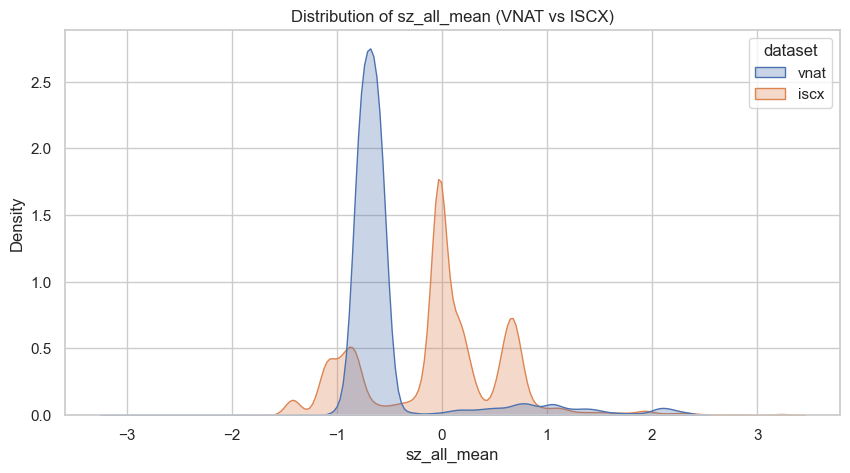

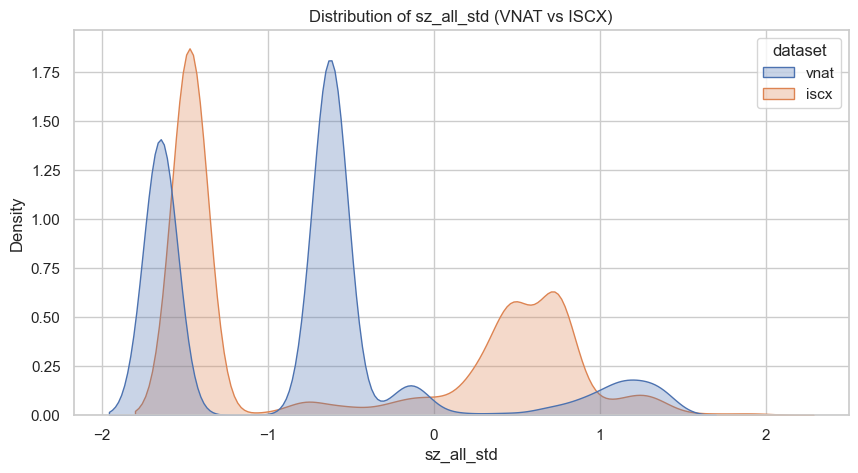

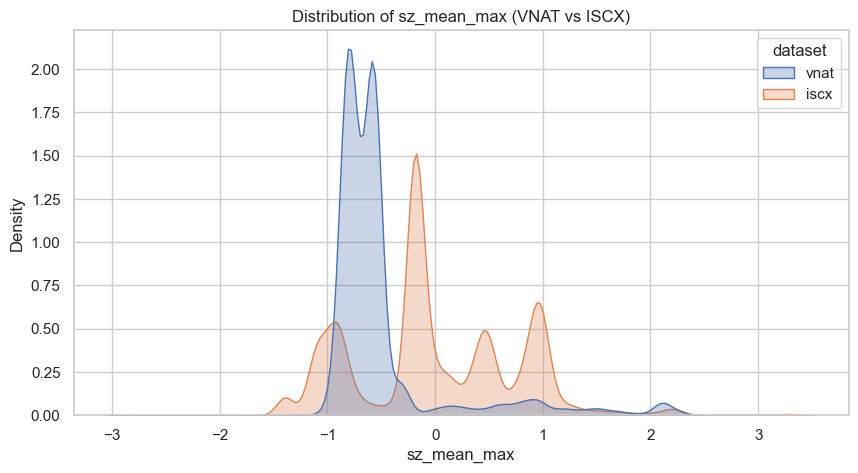

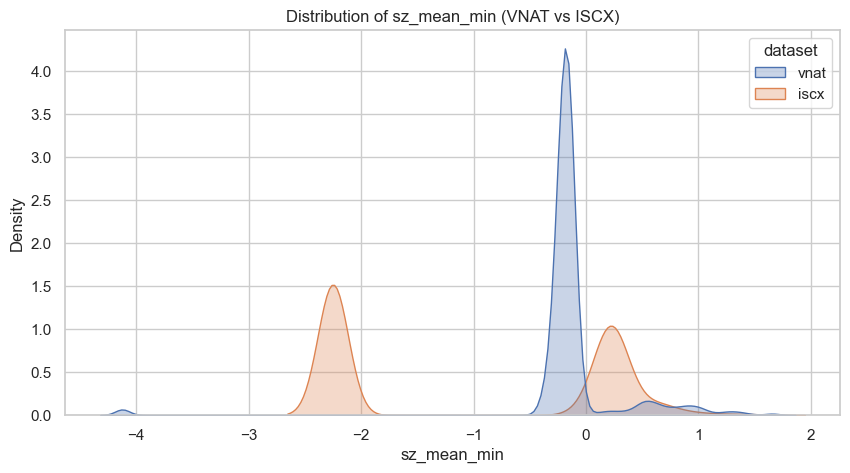

In [9]:
# 3.1 VNAT vs ISCX Feature Shift
# Compare a few key features
key_features = [c for c in df_features.columns if "mean" in c or "std" in c][:4] # Pick first 4 stats

print(f"\nComparing features: {key_features}")

for feat in key_features:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df_features, x=feat, hue="dataset", common_norm=False, fill=True, alpha=0.3)
    plt.title(f"Distribution of {feat} (VNAT vs ISCX)")
    plt.show()



--- Train vs Test Feature Shift ---


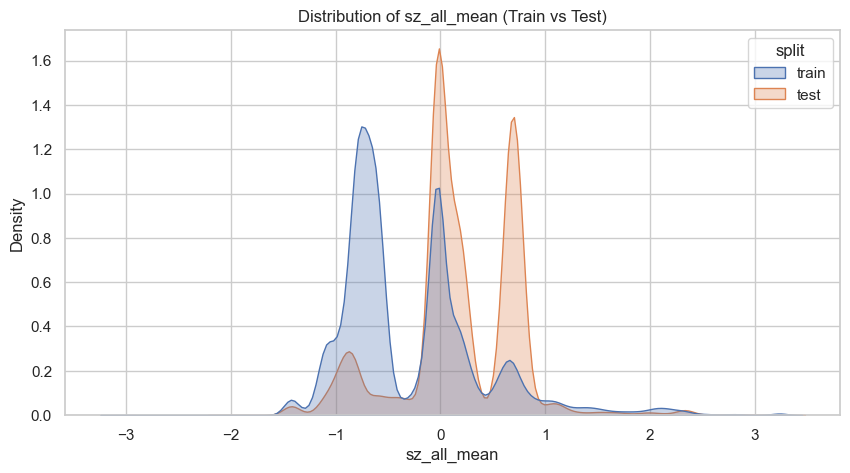

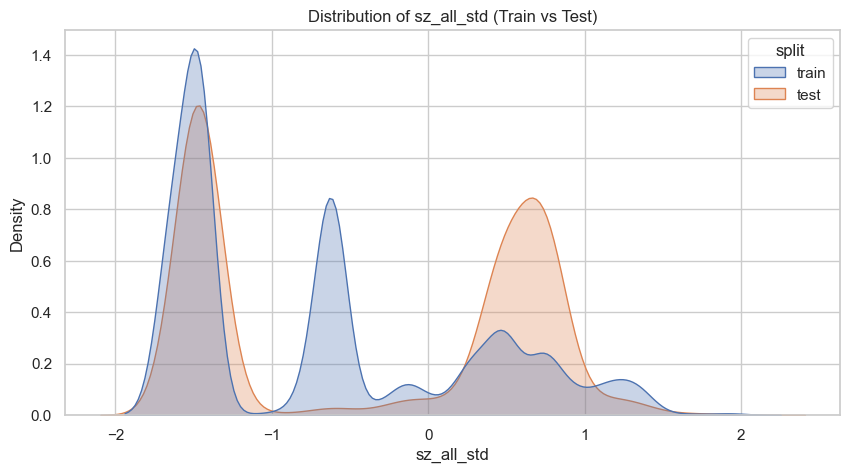

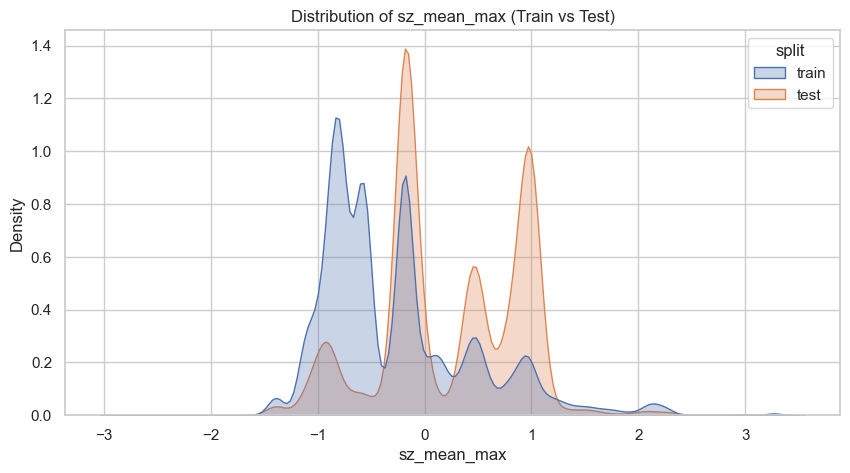

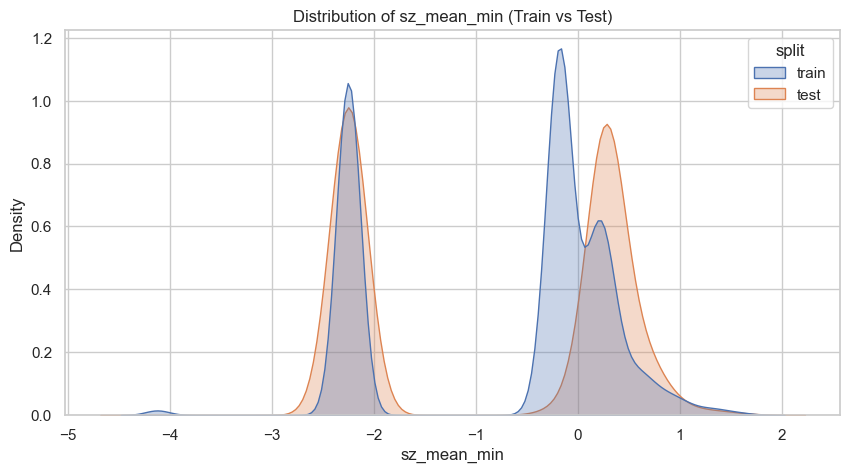

In [10]:
# 3.2 Train vs Test Feature Shift
# This checks if the splits are representative
print("\n--- Train vs Test Feature Shift ---")
for feat in key_features:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df_features[df_features["split"].isin(["train", "test"])], x=feat, hue="split", common_norm=False, fill=True, alpha=0.3)
    plt.title(f"Distribution of {feat} (Train vs Test)")
    plt.show()


In [11]:
# 3.3 Correlation Analysis
print("\n--- Correlation Analysis (Top 10 with Label) ---")
numeric_cols = df_features.select_dtypes(include=np.number).columns
corrs = df_features[numeric_cols].corrwith(df_features["label"]).sort_values(key=abs, ascending=False)
print(corrs.head(10))



--- Correlation Analysis (Top 10 with Label) ---
label            1.000000
h_iat_all_01     0.418027
h_iat_all_08     0.362837
sz_all_std       0.356198
h_iat_all_00    -0.287851
h_size_all_03    0.230064
sz_mean_max      0.195984
sz_mean_min      0.179836
h_size_all_00    0.163989
sz_all_p75       0.154700
dtype: float64
